<a href="https://colab.research.google.com/github/karegapauline/BHKi-projects/blob/main/HPC_project/HPC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

High-performance computing (HPC) is increasingly central to modern bioinformatics, genomics, public health, and environmental research. In Africa, growing participation in large-scale data-driven initiatives such as H3Africa has catalyzed investments in institutional and national HPC infrastructure. However, despite the presence of multiple HPC systems across the continent, evidence suggests persistent underutilization, restricted access, and misalignment between available computational resources and researcher needs.

We sort to investigate the extent of this situation by exploring existing grey and peer reviewed literature in Africa. The goal of this is to co-design a framework that would strengthen collaboration between regions that have particular strengths and weaknesses, and would benefit from collaboration.

## Method

1. Exploring grey and peer-reviewed literature

We scraped the websites for articles and information that related to High Performance computing infrastructure in Africa. We then manually explored information on their capacity, user accessibility, and training.

In [ ]:
pip install serpapi requests pandas tqdm

In [ ]:
import requests
import pandas as pd
from tqdm import tqdm

# ---------------- CONFIGURATION ----------------
SERPAPI_KEY = "084d87bb4b76b4a41d75b649eea9146c2aed325d1f5fbfa725dec24fd748bda3"

# Search focus
keywords = [
    "High Performance Computing Africa",
    "High Performance Computing Kenya",
    "High Performance Computing"
    "HPC bioinformatics Kenya",
    "HPC infrastructure Ghana",
    "HPC cluster Nigeria",
    "High Performance Computing Tanzania",
    "Supercomputing South Africa",
]

regions = ["Kenya", "Tanzania", "Ghana", "Nigeria", "South Africa"]

# Storage
records = []

# ---------------- FUNCTIONS ----------------
def search_grey_literature(query):
    """Use SerpAPI to pull URLs from Google for reports, PDFs, and institutional pages."""
    url = "https://serpapi.com/search.json"
    params = {
        "engine": "google",
        "q": query + " filetype:pdf OR site:.org OR site:.edu OR site:.ac.za",
        "api_key": SERPAPI_KEY,
        "num": 10,
    }
    r = requests.get(url, params=params)
    data = r.json()
    results = []
    for item in data.get("organic_results", []):
        results.append({
            "title": item.get("title"),
            "link": item.get("link"),
            "snippet": item.get("snippet"),
            "source": "Grey Literature"
        })
    return results


def search_crossref(query):
    """Query Crossref for academic publications."""
    url = f"https://api.crossref.org/works?query={query}&rows=10"
    r = requests.get(url)
    data = r.json()
    results = []
    for item in data.get("message", {}).get("items", []):
        results.append({
            "title": item.get("title", [""])[0],
            "link": item.get("URL"),
            "snippet": item.get("abstract", ""),
            "source": "Crossref"
        })
    return results


def search_semanticscholar(query):
    """Query Semantic Scholar for academic papers."""
    url = f"https://api.semanticscholar.org/graph/v1/paper/search?query={query}&limit=10&fields=title,url,abstract"
    r = requests.get(url)
    data = r.json()
    results = []
    for item in data.get("data", []):
        results.append({
            "title": item.get("title"),
            "link": item.get("url"),
            "snippet": item.get("abstract"),
            "source": "Semantic Scholar"
        })
    return results


# ---------------- MAIN LOOP ----------------
for kw in tqdm(keywords):
    try:
        grey = search_grey_literature(kw)
        cross = search_crossref(kw)
        sem = search_semanticscholar(kw)
        all_results = grey + cross + sem
        for r in all_results:
            r["query"] = kw
            records.append(r)
    except Exception as e:
        print(f"Error with {kw}: {e}")

# ---------------- OUTPUT ----------------
df = pd.DataFrame(records)
df.drop_duplicates(subset=["link"], inplace=True)
df.to_csv("HPC_literature_Africa.csv", index=False)

print(f"✅ Collected {len(df)} unique records. Saved to HPC_literature_Africa.csv.")


100%|██████████| 6/6 [00:06<00:00,  1.07s/it]

✅ Collected 106 unique records. Saved to HPC_literature_Africa.csv.


## Visualizing results

The following are visualizations about HPC locations, capacity and access in Africa.

In [20]:
pip install geodatasets


In [22]:
import geodatasets
import geopandas as gpd
#geodatasets.get_path("naturalearth.countries")

world = gpd.read_file('/content/drive/MyDrive/Colab Notebooks/ne_50m_admin_0_countries/ne_50m_admin_0_countries.shp')
world

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,None,None,None,None,None,None,None,None,None,"POLYGON ((31.28789 -22.40205, 31.19727 -22.344..."
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,None,None,None,None,None,None,None,None,None,"POLYGON ((30.39609 -15.64307, 30.25068 -15.643..."
2,Admin-0 country,1,3,Yemen,YEM,0,2,Sovereign country,1,Yemen,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((53.08564 16.64839, 52.58145 16..."
3,Admin-0 country,3,2,Vietnam,VNM,0,2,Sovereign country,1,Vietnam,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((104.06396 10.39082, 104.08301 ..."
4,Admin-0 country,5,3,Venezuela,VEN,0,2,Sovereign country,1,Venezuela,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-60.82119 9.13838, -60.94141 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,Admin-0 country,1,3,Afghanistan,AFG,0,2,Sovereign country,1,Afghanistan,...,None,None,None,None,None,None,None,None,None,"POLYGON ((66.52227 37.34849, 66.82773 37.37129..."
238,Admin-0 country,1,5,Kashmir,KAS,0,2,Indeterminate,None,Siachen Glacier,...,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,Unrecognized,"POLYGON ((77.04863 35.10991, 77.00449 35.19634..."
239,Admin-0 country,3,4,Antarctica,ATA,0,2,Indeterminate,1,Antarctica,...,None,None,None,None,None,None,None,None,None,"MULTIPOLYGON (((-45.71777 -60.5209, -45.49971 ..."
240,Admin-0 country,3,6,Netherlands,NL1,1,2,Country,1,Sint Maarten,...,None,None,None,None,None,None,None,None,None,"POLYGON ((-63.12305 18.06895, -63.01118 18.068..."


In [30]:
## code to put countries into continents
# Filter for African countries.
# Since there is no "continent" column, we define a list of country names
# within Africa to filter the dataset.
import pandas as pd

africa_countries = [
    "Algeria", "Angola", "Benin", "Botswana", "Burkina Faso", "Burundi",
    "Cabo Verde", "Cameroon", "Central African Republic", "Chad", "Comoros",
    "Democratic Republic of the Congo", "Djibouti", "Egypt", "Equatorial Guinea",
    "Eritrea", "Eswatini", "Ethiopia", "Gabon", "Gambia", "Ghana", "Guinea",
    "Guinea-Bissau", "Ivory Coast", "Kenya", "Lesotho", "Liberia", "Libya",
    "Madagascar", "Malawi", "Mali", "Mauritania", "Mauritius", "Morocco",
    "Mozambique", "Namibia", "Niger", "Nigeria", "Republic of the Congo",
    "Rwanda", "Sao Tome and Principe", "Senegal", "Seychelles", "Sierra Leone",
    "Somalia", "South Africa", "South Sudan", "Sudan", "Tanzania", "Togo",
    "Tunisia", "Uganda", "Zambia", "Zimbabwe"
]

# Clean the 'NAME' column in world before filtering
world['NAME'] = world['NAME'].astype(str).str.strip()

# Filter using the 'NAME' column or 'SOVEREIGNT' column in 50m data
africa = world[world['NAME'].isin(africa_countries)].copy()
africa =africa.to_crs(epsg=4326)

## The HPC systems that exist

data = [
    ("ZA-Wits-Core", "South Africa", 1348, -26.1929, 28.0305),
    ("CHPC", "South Africa", 32832, -33.9249, 18.4241),
    ("Ilifu", "South Africa", 1856, -33.9570, 18.4607),
    ("UCT HPC", "South Africa", 960, -33.9570, 18.4607),

    ("Discovery", "Ghana", 288, 6.6745, -1.5716),

    ("Virtual Lab - KENET", "Kenya", 176, -1.2921, 36.8219),
    ("Hpc01", "Kenya", 64, -1.2223, 36.8919),
    ("PUBReC", "Kenya", 16, -3.4905, 39.8440),
    ("ILRI", "Kenya", 128, -1.2706, 36.7240),

    ("UVRI Bioinformatics Cluster", "Uganda", 32, 0.0436, 32.4600),

    ("Pathogens Biology", "Malawi", 56, -15.7861, 35.0058),

    ("IPT", "Tunisia", 72, 36.8065, 10.1815),

    ("CUBRe", "Nigeria", 64, 6.6719, 3.1581),
    ("NABDA-CGRI", 8, 9.0579, 7.4951),

    ("ECBAG-EGYPT", "Egypt", 24, 30.5877, 31.5020),
]

df = pd.DataFrame(
    data,
    columns=["name", "country", "cores", "lat", "lon"]
)

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"
)


In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import pandas as pd
df2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/HPC_inventory_africa.csv")
df2

,"HPC Resource / Facility,""Country"",""City"",""Approx. Lat"",""Approx. Lon"",""CPU Cores"",""RAM (GB)"",""Max RAM per Node (GB)"",""Storage (TB)"",""GPUs"",""Job Scheduler"",""Accessibility / Access Type"",""Source(s)"""
0,"Toubkal Supercomputer (ASCC),""Morocco"",""Ben Gu..."
1,"Lengau Cluster (CHPC),""South Africa"",""Cape Tow..."
2,"BA-HPC-C2 (Bibliotheca Alexandrina),""Egypt"",""A..."
3,"Ilifu (UCT/UWC/Stellenbosch/SARAO),""South Afri..."
4,"UCT HPC,""South Africa"",""Cape Town"",""-33.9"",""18..."
5,"Stellenbosch HPC1 (Rhasatsha),""South Africa"",""..."
6,"Stellenbosch CAF-HPC1,""South Africa"",""Stellenb..."
7,"ZA-Wits-Core (Wits University),""South Africa"",..."
8,"CBIO Cluster (UCT/H3ABioNet),""South Africa"",""C..."
9,"RUBi (Rhodes University),""South Africa"",""Graha..."


First, let's correct the loading of the CSV file, as it seems to have been read as a single column. Then we'll merge it with the `africa` GeoDataFrame.

In [32]:
import pandas as pd
import csv
import io

filepath = "/content/drive/MyDrive/Colab Notebooks/HPC_inventory_africa.csv"

# Read the file content as raw lines, using 'utf-8-sig' to handle BOM
with open(filepath, 'r', encoding='utf-8-sig') as f:
    lines = f.readlines()

# Function to robustly clean and split a CSV line
def clean_and_split_line(line_str):
    # Remove leading/trailing whitespace
    line_str = line_str.strip()

    # If the entire line is wrapped in an extra set of quotes, remove them
    if line_str.startswith('"') and line_str.endswith('"'):
        line_str = line_str[1:-1]

    # Replace escaped quotes ("" -> ")
    line_str = line_str.replace('""', '"')

    # Use csv.reader for reliable splitting of fields
    # Create a StringIO object to treat the string as a file
    reader = csv.reader(io.StringIO(line_str), delimiter=',', quotechar='"')
    return next(reader)

# Parse header
header = clean_and_split_line(lines[0])

# Clean and parse data rows
parsed_data = []
num_header_cols = len(header)

for line in lines[1:]:
    if not line.strip(): # Skip empty lines
        continue
    try:
        row_data = clean_and_split_line(line)
        if len(row_data) == num_header_cols:
            parsed_data.append(row_data)
        else:
            # Optionally warn or log malformed rows
            print(f"Warning: Skipping row due to column count mismatch. Expected {num_header_cols}, got {len(row_data)}. Line: {line.strip()[:100]}...")
    except Exception as e:
        print(f"Error parsing line: {line.strip()[:100]}... Error: {e}")

# Create the DataFrame
df2_corrected = pd.DataFrame(parsed_data, columns=header)
display(df2_corrected)

,HPC Resource / Facility,Country,City,Approx. Lat,Approx. Lon,CPU Cores,RAM (GB),Max RAM per Node (GB),Storage (TB),GPUs,Job Scheduler,Accessibility / Access Type,Source(s)
0,Toubkal Supercomputer (ASCC),Morocco,Ben Guerir,32.2,-7.9,"69,000+",Not specified,Not specified,"8,000+",Not specified,Not specified,"Research support (climate, physics, AI, genomi...",
1,Lengau Cluster (CHPC),South Africa,Cape Town,-33.9,18.4,"32,832",Not specified,"1,024","5,000",30 Nvidia V100,PBSPro,"Project-based; Open to CHPC users, SADC, SKA p...",
2,BA-HPC-C2 (Bibliotheca Alexandrina),Egypt,Alexandria,31.2,29.9,Not specified,Not specified,Not specified,Not specified,Not specified,Not specified,Researchers at Egypt's universities & institutes,
3,Ilifu (UCT/UWC/Stellenbosch/SARAO),South Africa,Cape Town,-33.9,18.4,"1,856",Avg 7.5/core,512,"1,200",Not specified,Slurm,Limited access for H3A Projects & researchers,
4,UCT HPC,South Africa,Cape Town,-33.9,18.4,960,Avg 9.4/core,375,345,NVIDIA A100,Slurm,UCT collaborators; UCT PI approval; Institutio...,
5,Stellenbosch HPC1 (Rhasatsha),South Africa,Stellenbosch,-33.9,18.9,"1,272",Not specified,512,"1,000+",Not specified,PBS/Torque,All registered campus users (free 1000 CPU hou...,
6,Stellenbosch CAF-HPC1,South Africa,Stellenbosch,-33.9,18.9,448,Not specified,"1,024",Not specified,Not specified,PBS/Torque,Registered users only,
7,ZA-Wits-Core (Wits University),South Africa,Johannesburg,-26.2,28.0,"1,348",Avg 6.7/core,"1,024","1,300",Not specified,Slurm,Limited access for H3A Projects & researchers,
8,CBIO Cluster (UCT/H3ABioNet),South Africa,Cape Town,-33.9,18.4,336,8/core,"1,024",300,Not specified,PBS/Torque,Limited access,
9,RUBi (Rhodes University),South Africa,Grahamstown,-33.3,26.5,256,6.5/core,512,23,Not specified,PBS/Torque,"H3A projects, researchers & collaborators",


Now that `df2_corrected` is loaded properly, we can merge the `africa` GeoDataFrame with this new data. We will merge `africa` with `df2_corrected` using the `NAME` column from `africa` and the `Country` column from `df2_corrected`.

In [26]:
# Merge africa with df2_corrected
merged_africa_hpc = africa.merge(
    df2_corrected,
    how="left",
    left_on="NAME", # Column in africa GeoDataFrame
    right_on="Country" # Column in df2_corrected DataFrame
)

# Display the first few rows of the merged GeoDataFrame
display(merged_africa_hpc.head())

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,Approx. Lat,Approx. Lon,CPU Cores,RAM (GB),Max RAM per Node (GB),Storage (TB),GPUs,Job Scheduler,Accessibility / Access Type,Source(s)
0,Admin-0 country,1,3,Zimbabwe,ZWE,0,2,Sovereign country,1,Zimbabwe,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Admin-0 country,1,3,Zambia,ZMB,0,2,Sovereign country,1,Zambia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Admin-0 country,1,3,Uganda,UGA,0,2,Sovereign country,1,Uganda,...,0.3,32.6,Not specified,Not specified,Not specified,Not specified,Not specified,Not specified,Regional bioinformatics resource for East Afri...,
3,Admin-0 country,1,3,Uganda,UGA,0,2,Sovereign country,1,Uganda,...,0.0,32.4,32,4/core,128,5,Not specified,Slurm,Requires requisition & PI approval,
4,Admin-0 country,1,3,Tunisia,TUN,0,2,Sovereign country,1,Tunisia,...,36.8,10.2,72,72 - 512/core,"1,024",22,Not specified,None,Project members & collaborators,


## Capacity in Africa

South Africa has dominates in the number of cores, storage capacity (TB-PB scale), scheduler maturity and integration or federated cluster systems.

East Africa has fewer HPCs with less cores. Kenya, and Uganda have open information about this.

West africa have small to midsize clusters with limited storage and often operating as single institutions.

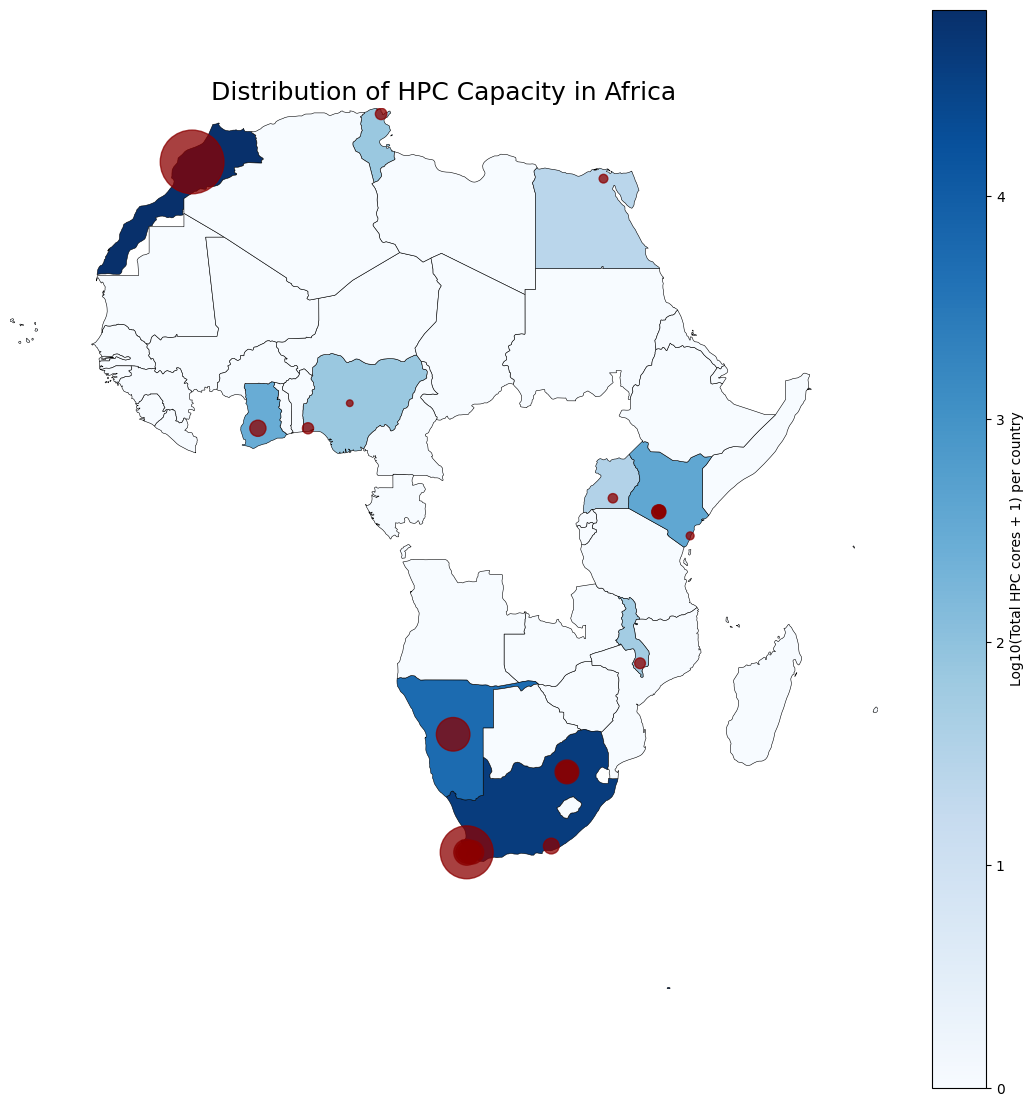

In [41]:
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd

# --- Function to clean and convert core counts (re-introduced for this cell) ---
def clean_core_count(core_str):
    if pd.isna(core_str) or str(core_str).lower() == 'not specified' or str(core_str).strip() == '':
        return np.nan
    # Remove +, ~, commas
    core_str = str(core_str).replace('+', '').replace('~', '').replace(',', '').strip()
    # Handle ranges (e.g., '2.0 - 3.2')
    if '-' in core_str:
        parts = core_str.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    try:
        return float(core_str)
    except ValueError:
        return np.nan

# --- Prepare df2_corrected data ---
hpc_data_for_plotting = df2_corrected.copy()

# Ensure 'Country' column is clean before grouping and merging
hpc_data_for_plotting['Country'] = hpc_data_for_plotting['Country'].astype(str).str.strip()

# Convert Lat/Lon to numeric, coercing errors to NaN
hpc_data_for_plotting['Approx. Lat'] = pd.to_numeric(hpc_data_for_plotting['Approx. Lat'], errors='coerce')
hpc_data_for_plotting['Approx. Lon'] = pd.to_numeric(hpc_data_for_plotting['Approx. Lon'], errors='coerce')

# Apply core cleaning function
hpc_data_for_plotting['CPU Cores Cleaned'] = hpc_data_for_plotting['CPU Cores'].apply(clean_core_count)

# Drop rows where Lat/Lon or CPU Cores Cleaned are NaN, as they cannot be plotted
hpc_data_for_plotting.dropna(subset=['Approx. Lat', 'Approx. Lon', 'CPU Cores Cleaned'], inplace=True)

# Create a GeoDataFrame for individual HPC points
hpc_gdf = gpd.GeoDataFrame(
    hpc_data_for_plotting,
    geometry=gpd.points_from_xy(hpc_data_for_plotting['Approx. Lon'], hpc_data_for_plotting['Approx. Lat']),
    crs="EPSG:4326"
)

# Calculate country capacity from the new hpc_gdf
country_capacity = (
    hpc_gdf
    .groupby("Country", as_index=False)
    .agg(
        total_cores=("CPU Cores Cleaned", "sum"),
        hpc_sites=("HPC Resource / Facility", "count")
    )
)

# Create a copy of africa to work with and clean its 'NAME' column for merging
africa_temp = africa.copy()
africa_temp['NAME'] = africa_temp['NAME'].astype(str).str.strip()

# Merge africa with the new country_capacity
africa_with_capacity = africa_temp.merge(
    country_capacity,
    how="left",
    left_on="NAME", # Column in africa GeoDataFrame
    right_on="Country" # Column in country_capacity DataFrame
)

# Fill NaN total_cores with 0 for countries without HPCs
africa_with_capacity["total_cores"] = africa_with_capacity["total_cores"].fillna(0)

# Calculate log10 for total cores for color mapping
africa_with_capacity["log_total_cores"] = np.log10(africa_with_capacity["total_cores"] + 1)

# Scale individual HPC cores for bubble size
hpc_gdf["scaled_cores"] = np.sqrt(hpc_gdf["CPU Cores Cleaned"])

# --- Plotting ---
fig, ax = plt.subplots(1, 1, figsize=(14, 14))

# Plot Africa base map (color by total cores)
africa_with_capacity.plot(
    ax=ax,
    column="log_total_cores",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.4,
    legend_kwds={
        "label": "Log10(Total HPC cores + 1) per country",
        "orientation": "vertical"
    }
)

# Force correct extent (critical)
ax.set_xlim(africa.total_bounds[[0, 2]])
ax.set_ylim(africa.total_bounds[[1, 3]])

# Plot individual HPC site-level capacity bubbles
hpc_gdf.plot(
    ax=ax,
    color="darkred",
    markersize=hpc_gdf["scaled_cores"] * 8, # Adjust multiplier as needed for visualization
    alpha=0.75,
    zorder=5,
    label="Individual HPC Sites"
)

ax.set_title("Distribution of HPC Capacity in Africa", fontsize=18)
ax.set_axis_off()
plt.savefig('capacity_plot_image.png')
plt.show()


## Availability, Access and usage summary

In SA accessibility is limited to the institutional staff, and collaborators, or funded projects and requiring strict approval.

In East Africa accessibility is limited to the institutional staff, and funded projects with strict approval. Commercial spaces managed nationally like KENET also exist but at a cost. They however have strong communities across the Coast and Nairobi, linked by funded projects. No records of cross communication between countries is visible, for example between Uganda and Kenya.

West Africa has a growing network of clusters as well. we dound a university hosted platform, and multiple commercial systems.

North Africa also has HPCs.

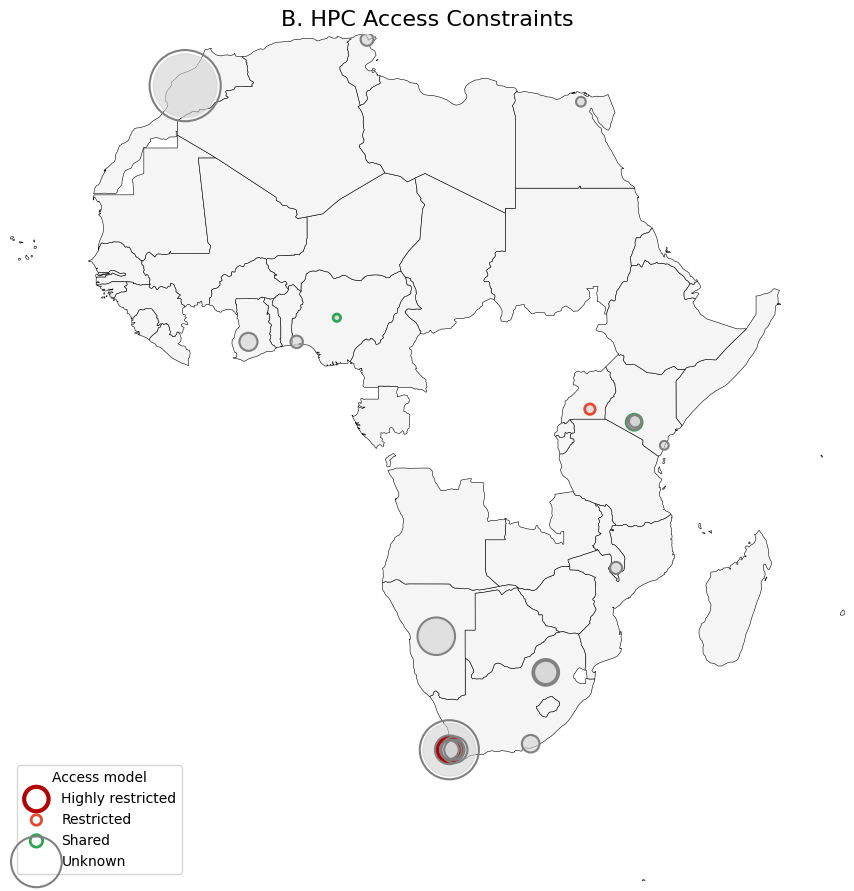

In [43]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Function to clean and convert core counts (copied for independence) ---
def clean_core_count(core_str):
    if pd.isna(core_str) or str(core_str).lower() == 'not specified' or str(core_str).strip() == '':
        return np.nan
    # Remove +, ~, commas
    core_str = str(core_str).replace('+', '').replace('~', '').replace(',', '').strip()
    # Handle ranges (e.g., '2.0 - 3.2')
    if '-' in core_str:
        parts = core_str.split('-')
        try:
            return (float(parts[0]) + float(parts[1])) / 2
        except ValueError:
            return np.nan
    try:
        return float(core_str)
    except ValueError:
        return np.nan

# ---- ACCESS TIERS (from original cell) ----
access_map = {
    "ZA-Wits-Core": "Limited",
    "CHPC": "National / Project-based",
    "Ilifu": "Limited",
    "UCT HPC": "Institutional",
    "Discovery": "Institutional",
    "Virtual Lab - KENET": "Consortium",
    "Hpc01": "Project-based",
    "UVRI Bioinformatics Cluster": "Project-based",
    "PUBReC": "Collaborative",
    "Pathogens Biology": "Collaborative",
    "IPT": "Project-based",
    "CUBRe": "Project-based",
    "NABDA-CGRI": "Collaborative",
    "ECBAG-EGYPT": "Collaborative"
}

access_tier_map = {
    "National / Project-based": "Highly restricted",
    "Institutional": "Highly restricted",
    "Limited": "Restricted",
    "Project-based": "Restricted",
    "Consortium": "Shared",
    "Collaborative": "Shared"
}

# --- Prepare df2_corrected data to create hpc_gdf_for_access_plotting ---
hpc_data_for_access_plotting = df2_corrected.copy()

# Convert Lat/Lon to numeric, coercing errors to NaN
hpc_data_for_access_plotting['Approx. Lat'] = pd.to_numeric(hpc_data_for_access_plotting['Approx. Lat'], errors='coerce')
hpc_data_for_access_plotting['Approx. Lon'] = pd.to_numeric(hpc_data_for_access_plotting['Approx. Lon'], errors='coerce')

# Apply core cleaning function
hpc_data_for_access_plotting['CPU Cores Cleaned'] = hpc_data_for_access_plotting['CPU Cores'].apply(clean_core_count)

# Drop rows where Lat/Lon or CPU Cores Cleaned are NaN, as they cannot be plotted
hpc_data_for_access_plotting.dropna(subset=['Approx. Lat', 'Approx. Lon', 'CPU Cores Cleaned'], inplace=True)

# Create a GeoDataFrame for individual HPC points from df2_corrected
hpc_gdf_for_access_plotting = gpd.GeoDataFrame(
    hpc_data_for_access_plotting,
    geometry=gpd.points_from_xy(hpc_data_for_access_plotting['Approx. Lon'], hpc_data_for_access_plotting['Approx. Lat']),
    crs="EPSG:4326"
)

# Calculate scaled_cores for sizing the bubbles
hpc_gdf_for_access_plotting["scaled_cores"] = np.sqrt(hpc_gdf_for_access_plotting["CPU Cores Cleaned"])

# Map access models and tiers to the new GeoDataFrame
hpc_gdf_for_access_plotting["access_model"] = hpc_gdf_for_access_plotting["HPC Resource / Facility"].map(access_map)
hpc_gdf_for_access_plotting["access_tier"] = hpc_gdf_for_access_plotting["access_model"].map(access_tier_map)

# Fill NaN access_tier with 'Unknown' for plotting if not explicitly in access_map
hpc_gdf_for_access_plotting['access_tier'] = hpc_gdf_for_access_plotting['access_tier'].fillna('Unknown')

# ---- VISUAL STYLES (updated to include 'Unknown') ----
access_style = {
    "Highly restricted": {"edgecolor": "#b30000", "linewidth": 3},
    "Restricted": {"edgecolor": "#e34a33", "linewidth": 2},
    "Shared": {"edgecolor": "#31a354", "linewidth": 2},
    "Unknown": {"edgecolor": "grey", "linewidth": 1.5} # Added for entries not in access_map
}

# ---- FIGURE ----
fig, ax2 = plt.subplots(1, 1, figsize=(22, 11))

# =====================
# PANEL B: ACCESS
# =====================
africa.plot(
    ax=ax2,
    color="whitesmoke",
    edgecolor="black",
    linewidth=0.4
)

ax2.set_xlim(africa.total_bounds[[0, 2]])
ax2.set_ylim(africa.total_bounds[[1, 3]])

# Base capacity (neutral fill) - now using hpc_gdf_for_access_plotting
hpc_gdf_for_access_plotting.plot(
    ax=ax2,
    color="lightgrey",
    markersize=hpc_gdf_for_access_plotting["scaled_cores"] * 8,
    alpha=0.6,
    zorder=3
)

# Access rings - now using hpc_gdf_for_access_plotting
for tier, style in access_style.items():
    subset = hpc_gdf_for_access_plotting[hpc_gdf_for_access_plotting["access_tier"] == tier]
    # Only plot if there are sites for this tier
    if not subset.empty:
        subset.plot(
            ax=ax2,
            facecolor="none",
            markersize=subset["scaled_cores"] * 10, # Slightly larger for rings
            edgecolor=style["edgecolor"],
            linewidth=style["linewidth"],
            label=tier,
            zorder=5
        )

ax2.legend(
    title="Access model",
    loc="lower left",
    frameon=True
)

ax2.set_title("B. HPC Access Constraints", fontsize=16)
ax2.set_axis_off()

plt.savefig('access_plot_image.png')
plt.show()


## Problem and proposal
Kenya's strengths are on strong networks, and infrastructures, but weaknesses on shared compute and underutilization. They also have active communities like bioinformatics communities with evidence of shared training. West african countries like Nigeria, and Ghana have multiple systems available, but have very small systems relative to demand, we assume.


## Co-designing for access

The current access protocols. This section summarises the existing access modes mentioned for the different HPCs. The forms, communication plans in place to request space, requirements and more.

Using these to inform co-designing of the framework. (come up with a report that we can share with our selected partners about communication that works or doesn't work in this work).


## Co-designing training
What type is training is required to ensure users are maximising the HPC use? So:
- Training to enable users to gauge what they need (if they actually need a HPC or can use a smaller system) in a HPC system.
- Writing a DMP that can be shared with the technical team as the project begins to use to determine their needs, and any changes, and sustain this for after the project is complete (can the data be reused by any other person coming in later using the same data)
- Writing metadata and documentation (for reuse of data and workflow in future with new users)
- Communicating errors or issues with the technical team
- Optimizing use of the space (to get the best output of their project)
- How best to use the HPC based on geographic location (based on what exists, their needs, and the collab framework)

The output will be a report to guide that can be used to design the best training material. This will be implemented to design these training materials for use with the selected cohort.   

So, co-design material with the system administrators, those who manage the system.

End users come in in the training part.

Strategy for approaching institutions to test the co-design framework.
